# Inferencia Causal y Uplift Modeling: Optimizando el ROI

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/inferencia_causal_uplift_modeling.ipynb)



## Objetivos del Caso de Estudio


- **Perspectiva de Negocio:** Dejar de predecir *quién va a comprar* para empezar a predecir *quién va a comprar SÓLO SI le damos un incentivo*. Maximizar el Retorno de Inversión (ROI) de las campañas de marketing.
- **Perspectiva de Ingeniería:** Comprender el Problema Fundamental de la Inferencia Causal (la imposibilidad de observar contrafactuales) y cómo los A/B Tests (RCTs) nos permiten sortearlo.
- **Implementación:** Programar un **T-Learner** (Two-Model Approach) desde cero utilizando algoritmos clásicos (XGBoost/Random Forest) para calcular el *Treatment Effect* individual.
- **Evaluación Avanzada:** Construir e interpretar una Curva de Ganancia Acumulada (*Cumulative Uplift Curve*) para evaluar modelos causales en producción.



## Prerrequisitos


- Entendimiento de modelos de clasificación probabilística.
- Calibración y Curvas de Ganancia

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    subprocess.run(["pip", "install", "xgboost"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## 1. Introducción: El Engaño de la Predicción Tradicional


Imaginemos que trabajamos en un E-Commerce. El equipo de Marketing tiene presupuesto para enviar un cupón de `$10` de descuento a 5.000 clientes. Y nos piden un modelo de Machine Learning para elegir a quién enviárselo.

El enfoque tradicional (*Propensity Modeling*) es entrenar un XGBoost para predecir la probabilidad de que un cliente compre, y enviarle el cupón a los que tienen mayor probabilidad.

**⚠️ Error Multimillonario:**  
Si le enviamos un descuento a alguien que *ya iba a comprar de todas formas*, no generamos una venta nueva; **acabamos de perder $10**. El Machine Learning tradicional predice el resultado (la compra), pero ignora la **causalidad** (¿compró *por culpa* del cupón?).

### Los 4 Cuadrantes del Marketing (La Matriz Causal)


En la inferencia causal, dividimos a los clientes en 4 grupos latentes (inobservables en la vida real):

1. **Persuadables (Los que queremos):** Compran SI reciben el cupón. No compran si no lo reciben. (El cupón causa la venta).
2. **Sure Things (Causas Seguras):** Compran reciban o no el cupón. (Darles el cupón es tirar dinero).
3. **Lost Causes (Causas Perdidas):** No compran nunca, con o sin cupón. (Darles el cupón es tirar dinero).
4. **Sleeping Dogs (Perros Dormidos):** ¡El caso más peligroso! Compran si NO reciben el cupón. Si lo enviamos, se molestan (ej. les recordamos que están suscritos a un servicio que no usan) y cancelan. (El cupón causa la pérdida).

El **Uplift Modeling** es la rama de la IA que busca identificar exclusivamente a los *Persuadables*.

## 2. El Laboratorio: Generación de Datos Causales


El "Problema Fundamental de la Inferencia Causal" es que no podemos observar a la misma persona en dos universos paralelos al mismo tiempo (con cupón y sin cupón).

Para este laboratorio, somos (de nuevo) los "Dioses" de los datos. Así que generamos un dataset sintético donde **sí conocemos el universo paralelo** (el contrafactual) para poder medir si nuestro modelo realmente funciona.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

np.random.seed(42)
n_samples = 20000

# 1. Generamos características de los clientes
edad = np.random.uniform(18, 65, n_samples)
ingreso = np.random.normal(50000, 15000, n_samples)
compras_previas = np.random.poisson(3, n_samples)

X = pd.DataFrame({'edad': edad, 'ingreso': ingreso, 'compras_previas': compras_previas})

# 2. Probabilidad Base (Control): ~25% en promedio.
# Los de altos ingresos y muchas compras previas tienen alta prob base (Sure Things)
logit_control = -3.5 + (ingreso / 20000) + (compras_previas * 0.3)
prob_control = 1 / (1 + np.exp(-logit_control))

# 3. Efecto Causal (Uplift Real):
efecto_cupon = np.zeros(n_samples)
# Persuadables: Jóvenes (+35% de probabilidad si reciben cupón)
efecto_cupon += (edad < 35) * 0.35
# Sleeping Dogs: Clientes muy frecuentes se molestan con el spam (-25% de probabilidad)
efecto_cupon -= (compras_previas >= 5) * 0.25
# Sure Things: A los de ingresos muy altos el cupón no les cambia nada (0% uplift)
efecto_cupon[(ingreso > 65000)] = 0.0

# Probabilidad final con tratamiento
prob_tratamiento = np.clip(prob_control + efecto_cupon, 0, 1)

# Recalculamos el uplift real exacto post-clipping
uplift_real_oculto = prob_tratamiento - prob_control

# 4. Asignamos el Tratamiento (A/B Test Aleatorio 50/50)
tratamiento = np.random.binomial(1, 0.5, n_samples)

# 5. Observamos el resultado final (y)
y_observado = np.where(tratamiento == 1,
                       np.random.binomial(1, prob_tratamiento),
                       np.random.binomial(1, prob_control))

df = X.copy()
df['tratamiento'] = tratamiento
df['compra'] = y_observado
df['uplift_real_oculto'] = uplift_real_oculto # El Ground Truth

print(f"Total de clientes: {len(df)}")
print(f"Tasa de compra Grupo Control:    {df[df['tratamiento']==0]['compra'].mean()*100:.2f}%")
print(f"Tasa de compra Grupo Tratamiento: {df[df['tratamiento']==1]['compra'].mean()*100:.2f}%")
print(f"Uplift Promedio Global (ATE):     {(df[df['tratamiento']==1]['compra'].mean() - df[df['tratamiento']==0]['compra'].mean())*100:.2f}%")

# División Train/Test
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

Total de clientes: 20000
Tasa de compra Grupo Control:    47.57%
Tasa de compra Grupo Tratamiento: 54.02%
Uplift Promedio Global (ATE):     6.45%


El A/B Test nos dice que el cupón aumenta las ventas un `~6,5%` en promedio. Pero enviar el cupón a todos es ineficiente. Queremos encontrar a los individuos específicos donde el efecto es del `+35%` (Persuadables) y evitar a los del `-15%` (Sleeping Dogs).

## 3. El Enfoque Tradicional (Mala Práctica)



Veamos qué pasa si un Científico de Datos tradicional entrena un modelo para predecir simplemente `compra == 1`, ignorando la causalidad.



In [7]:
# Entrenamos un modelo para predecir la COMPRA
modelo_tradicional = XGBClassifier(random_state=42, eval_metric='logloss')
# Usamos solo las features, ignoramos la columna de tratamiento
modelo_tradicional.fit(df_train[['edad', 'ingreso', 'compras_previas']], df_train['compra'])

# Predecimos la probabilidad de compra en el Test Set
df_test = df_test.copy()
df_test['prob_compra_tradicional'] = modelo_tradicional.predict_proba(df_test[['edad', 'ingreso', 'compras_previas']])[:, 1]

# Si el equipo de marketing elige a los 1000 clientes con mayor probabilidad de compra:
top_1000_tradicional = df_test.nlargest(1000, 'prob_compra_tradicional')

print("--- Perfil de los clientes seleccionados por el Modelo Tradicional ---")
print(f"Probabilidad media de compra: {top_1000_tradicional['prob_compra_tradicional'].mean()*100:.2f}%")
print(f"Uplift Real (Efecto del cupón en ellos): {top_1000_tradicional['uplift_real_oculto'].mean()*100:.2f}%")

--- Perfil de los clientes seleccionados por el Modelo Tradicional ---
Probabilidad media de compra: 83.46%
Uplift Real (Efecto del cupón en ellos): 9.79%


**Análisis del Desastre:**  
El modelo tradicional seleccionó a clientes con una altísima probabilidad de compra (cercana al `83%`). ¡Pero su Uplift Real es de apenas `~9.8%`! (Apenas unos puntos por encima del promedio global de la campaña).
¿Qué pasó? El modelo seleccionó mayoritariamente a los **Sure Things** (gente de altos ingresos que ya iba a comprar). Si les enviamos el cupón de `$10` a estos clientes, simplemente les estamos regalando dinero por una compra que iban a hacer de todas formas. El ROI de esta campaña será bajísimo porque estamos subsidiando ventas orgánicas.

## 4. Uplift Modeling: El Enfoque T-Learner (Two-Model)



Para predecir la causalidad, necesitamos predecir la diferencia entre dos universos. El enfoque más intuitivo y robusto en ingeniería es el **T-Learner** (Two-Learner).

1. Entrenamos un Modelo $M_T$ usando **solo** a los clientes que recibieron el cupón (`tratamiento == 1`).
2. Entrenamos un Modelo $M_C$ usando **solo** a los clientes que NO recibieron el cupón (`tratamiento == 0`).
3. Para un cliente nuevo, le pedimos a ambos modelos que predigan su probabilidad.
4. **Uplift Score** = $M_T(x) - M_C(x)$



In [8]:
# 1. Separamos los datos de entrenamiento por tratamiento
train_tratados = df_train[df_train['tratamiento'] == 1]
train_control = df_train[df_train['tratamiento'] == 0]

features = ['edad', 'ingreso', 'compras_previas']

# 2. Entrenamos los dos modelos
modelo_T = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_T.fit(train_tratados[features], train_tratados['compra'])

modelo_C = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_C.fit(train_control[features], train_control['compra'])

# 3. Calculamos el Uplift Score en el Test Set
prob_si_tratado = modelo_T.predict_proba(df_test[features])[:, 1]
prob_si_control = modelo_C.predict_proba(df_test[features])[:, 1]

df_test['uplift_score_predicho'] = prob_si_tratado - prob_si_control

# Si el equipo de marketing elige a los 1000 clientes con mayor UPLIFT:
top_1000_uplift = df_test.nlargest(1000, 'uplift_score_predicho')

print("--- Perfil de los clientes seleccionados por el T-Learner ---")
print(f"Uplift Real (Efecto del cupón en ellos): {top_1000_uplift['uplift_real_oculto'].mean()*100:.2f}%")

--- Perfil de los clientes seleccionados por el T-Learner ---
Uplift Real (Efecto del cupón en ellos): 27.52%


**El Triunfo de la Ingeniería:**  
¡El T-Learner seleccionó a un grupo de clientes donde el cupón genera casi un **`+28%` de incremento real en ventas**! (Casi triplicando la efectividad del modelo tradicional). El modelo ignoró a los ricos y a los compradores frecuentes, y se enfocó exclusivamente en los jóvenes de ingresos medios: los verdaderos Persuadables. Hemos optimizado el presupuesto al máximo.

## 5. Evaluación del Negocio: La Curva Qini (Uplift Curve)



En la vida real, no tenemos la columna `uplift_real_oculto` para verificar si nuestro modelo funciona. ¿Cómo evaluamos un modelo causal en producción?

Utilizamos la **Curva de Ganancia Acumulada de Uplift (Qini Curve)**.
La lógica es:
1. Ordenamos a todos los clientes del Test Set de mayor a menor `uplift_score_predicho`.
2. Vamos tomando deciles (el top 10%, top 20%, etc.).
3. En cada decil, miramos cuántos compraron en el grupo que *casualmente* tenía el cupón, y le restamos los que compraron en el grupo que *casualmente* no lo tenía.
4. Si el modelo es bueno, los primeros deciles tendrán una diferencia enorme a favor del tratamiento.

Vamos a programar esta curva desde cero para entender la matemática:

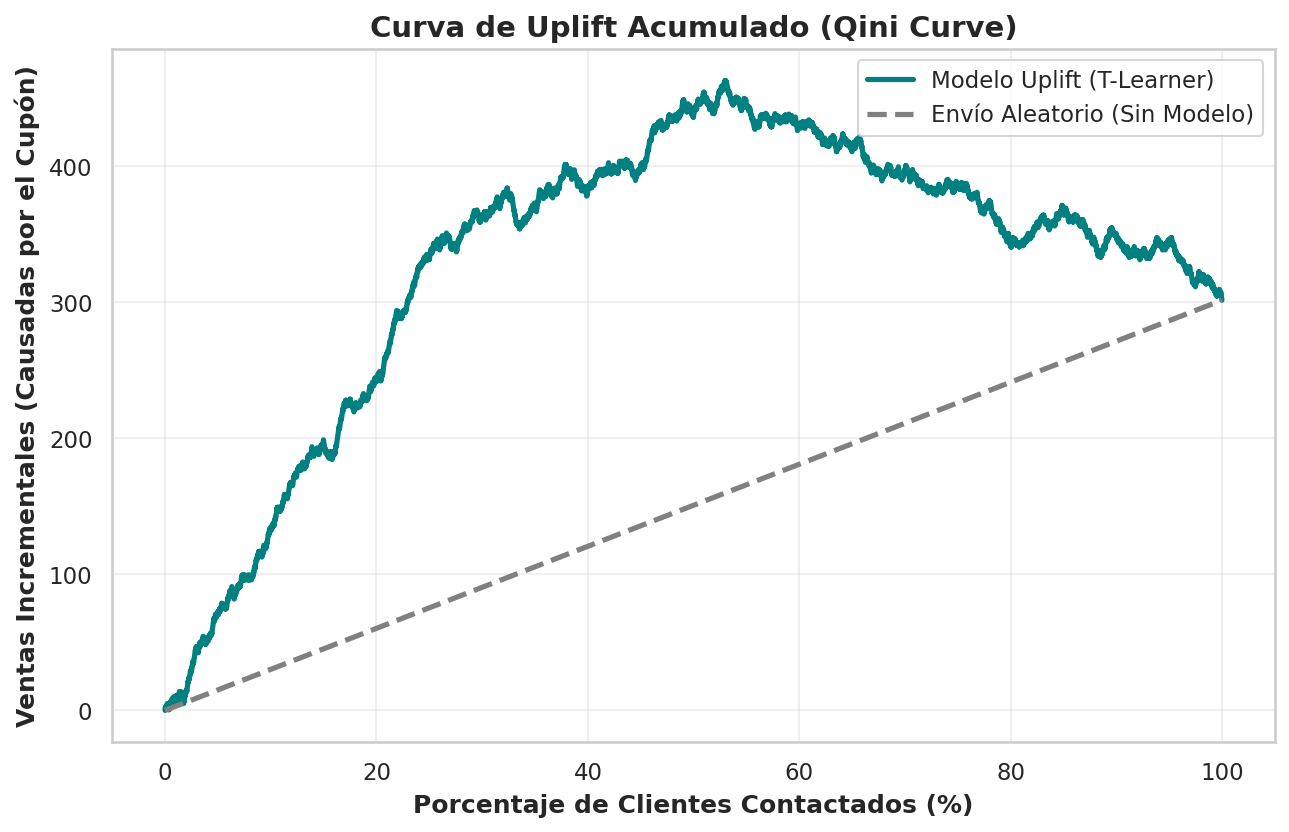

In [9]:
def plot_uplift_curve(df, score_col, treatment_col, target_col):
    # Ordenamos de mayor a menor score
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)

    # Calculamos conversiones acumuladas
    df_sorted['tratados_acum'] = df_sorted[treatment_col].cumsum()
    df_sorted['control_acum'] = (~df_sorted[treatment_col].astype(bool)).cumsum()

    df_sorted['compras_tratados_acum'] = (df_sorted[target_col] * df_sorted[treatment_col]).cumsum()
    df_sorted['compras_control_acum'] = (df_sorted[target_col] * (~df_sorted[treatment_col].astype(bool))).cumsum()

    # Evitamos división por cero
    df_sorted['tasa_tratados'] = df_sorted['compras_tratados_acum'] / np.maximum(df_sorted['tratados_acum'], 1)
    df_sorted['tasa_control'] = df_sorted['compras_control_acum'] / np.maximum(df_sorted['control_acum'], 1)

    # Uplift Acumulado = (Tasa Tratados - Tasa Control) * Total de personas hasta ese punto
    df_sorted['uplift_acumulado'] = (df_sorted['tasa_tratados'] - df_sorted['tasa_control']) * (df_sorted.index + 1)

    # Curva Aleatoria (Baseline sin modelo)
    uplift_total = df_sorted['uplift_acumulado'].iloc[-1]
    random_curve = np.linspace(0, uplift_total, len(df_sorted))

    # Graficamos
    plt.figure(figsize=(10, 6))
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['uplift_acumulado'], label='Modelo Uplift (T-Learner)', color='teal', linewidth=2.5)
    plt.plot(df_sorted.index / len(df_sorted) * 100, random_curve, label='Envío Aleatorio (Sin Modelo)', color='gray', linestyle='--')

    plt.title("Curva de Uplift Acumulado (Qini Curve)", fontsize=14)
    plt.xlabel("Porcentaje de Clientes Contactados (%)")
    plt.ylabel("Ventas Incrementales (Causadas por el Cupón)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Evaluamos nuestro T-Learner
plot_uplift_curve(df_test, 'uplift_score_predicho', 'tratamiento', 'compra')

### Análisis: Leyendo la Curva Qini


1. **La Línea Gris (Aleatoria):** Si enviamos cupones al azar, las ventas incrementales suben de forma lineal hasta llegar a unas `~300` ventas extra al contactar a toda la base.
2. **La Línea Verde (T-Learner):** La línea verde del T-Learner sube drásticamente al principio. Esto significa que contactando solo al **`~50%` de la base de datos** (los que tienen mayor Uplift Score), logramos el pico máximo de ventas incrementales (superando las `450` ventas extra).
3. **La Caída al Final (Sleeping Dogs):** Observar cómo la línea verde cae abruptamente si seguimos contactando clientes más allá del `60%` de la base. ¡Esos son los Sleeping Dogs! El modelo los dejó para el final porque sabía matemáticamente que enviarles el cupón destruiría ventas.

**Conclusión de Negocio**: Si la empresa contactara al 100% de la base (gastando el doble de dinero en marketing), obtendría **menos ventas totales** (`~300`) que si contactara solo a la mitad de la base guiada por el modelo (`~450`). ¡El Uplift Modeling acaba de salvar la rentabilidad del trimestre!

## 6. Conclusión y Matriz de Decisión


El Uplift Modeling es el puente definitivo entre el Machine Learning y el Retorno de Inversión (ROI) financiero.

| Escenario de Negocio | Enfoque Recomendado | Justificación |
| :--- | :--- | :--- |
| **Detección de Fraude / Diagnóstico Médico** | **Machine Learning Tradicional** | Queremos predecir un estado latente (Fraude/Enfermedad). No estamos aplicando un "tratamiento" para cambiar su comportamiento. |
| **Campañas de Retención (Churn) / Descuentos** | **Uplift Modeling (T-Learner)** | Queremos cambiar el comportamiento del usuario. Contactar a un usuario que se iba a quedar de todas formas (Sure Thing) es un desperdicio de recursos. |
| **Optimización de Precios (Pricing)** | **Inferencia Causal Continua** | Evaluar la elasticidad del precio. Requiere modelos causales más avanzados (ej. *Double Machine Learning*). |

**Regla de Oro:** Para entrenar un modelo de Uplift, **necesitamos datos de un A/B Test previo (*Randomized Controlled Trial*)**. Si los datos históricos están sesgados (ej. marketing solo le dio cupones a los clientes ricos en el pasado), el T-Learner aprenderá ese sesgo y fallará. La aleatoriedad en la recolección de datos es innegociable.

## Referencias


1. Gutierrez, P., & Gérardy, J. Y. (2016). *Causal inference and uplift modelling: A review of the literature*. JMLR: Workshop and Conference Proceedings 67 (pp. 1-13).
2. Radcliffe, N. J., & Surry, P. D. (2011). *Real-world uplift modelling with significance-based uplift trees*. White Paper TR-2011-1, Stochastic Solutions.
3. [CausalML: A Python Package for Causal Machine Learning](https://causalml.readthedocs.io/)

---

## Entorno de Ejecución


In [10]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
